In [2]:
import seaborn as sns
from sklearn.datasets import make_blobs


In [3]:
X, y=make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
    
)

<Axes: >

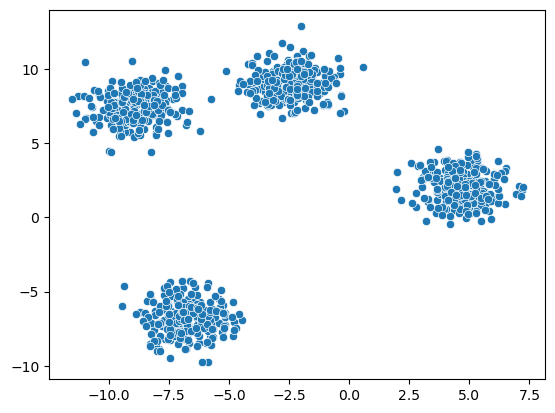

In [9]:
sns.scatterplot(x= X[:,0], y=X[:,1])

In [21]:
# kmeans clustering
import os
os.environ["OMP_NUM_THREADS"] = "4"
from sklearn.cluster import KMeans

In [24]:
K=4
kmeans=KMeans(
    n_clusters=K,
    
    random_state=42
)

In [25]:
labels=kmeans.fit_predict(X)

C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


<Axes: >

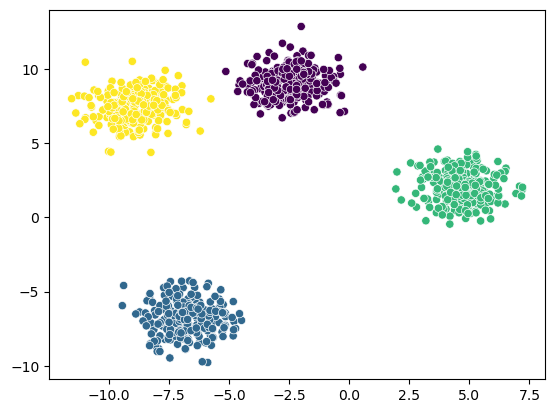

In [26]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=labels)

# choose kmeans value-elbow or silhoutte method


In [52]:
wcss=[]
for k in range(1,21):
    kmeans=KMeans(
        n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

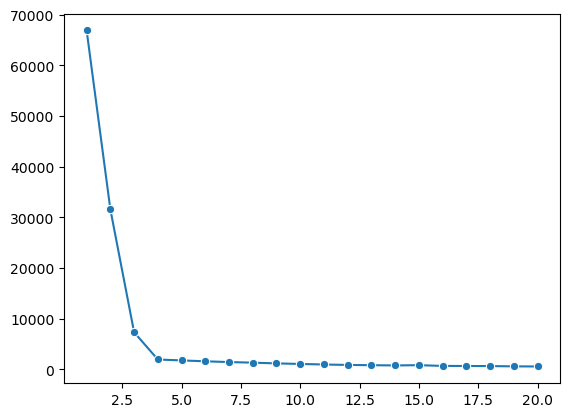

In [31]:
sns.lineplot(x=range(1,21),y=wcss,marker="o")

In [32]:
!pip install kneed

In [36]:
from kneed import KneeLocator

In [37]:
knee=KneeLocator(
    range(1,21),
    wcss,
    curve="convex",
    direction="decreasing"
)

In [40]:
print("optimal k=" ,knee.elbow)

optimal k= 4


In [50]:
# from sklearn.metrics import silhouette_score
# ss=[]
# for k in range(2,21):
#     kmeans=KMeans(n_clusters=k)
#     labels=kmeans.fit_predict(X)
#     score=silhouette_score(X,labels)
#     ss.append(score)

<Axes: >

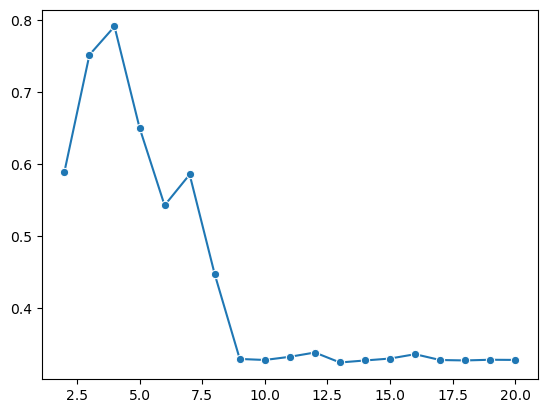

In [49]:
sns.lineplot(x=range(2,21),y=ss, marker="o")

In [56]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [54]:
iris=load_iris()

In [65]:
X=iris.data

y=iris.target

In [66]:
X.shape

(150, 4)

<Axes: >

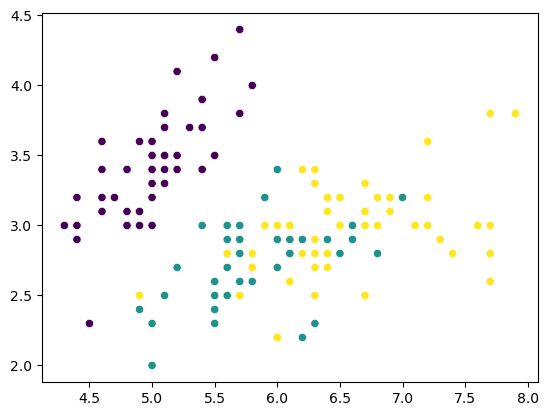

In [68]:
#visualize
sns.scatterplot(x=X[:,0], y=X[:,1], c=y)

In [73]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [103]:
#pca dimentionality reduction
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(X_scaled)

In [104]:
#kmeans value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

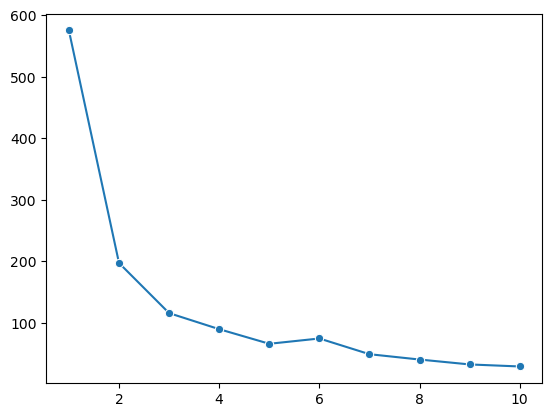

In [105]:
sns.lineplot(x=range(1,11) , y=wcss ,marker="o")

In [110]:
kmeans=KMeans(n_clusters=3,random_state=10)
labels=kmeans.fit_predict(pca_data)

C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

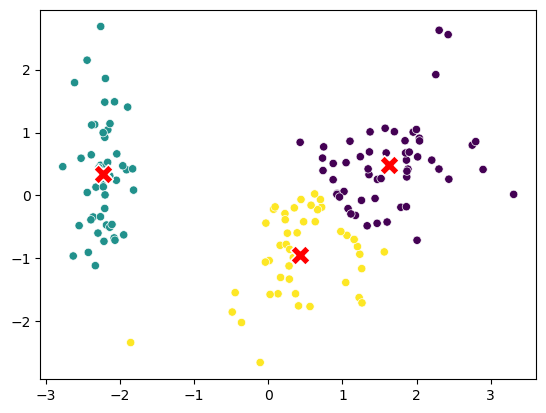

In [112]:
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker="X",c="red" ,s=200)

<Axes: >

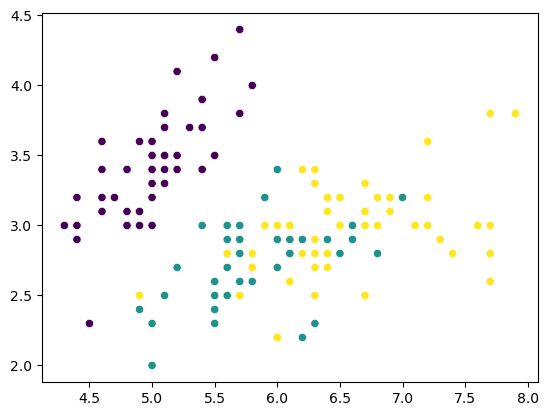

In [109]:
sns.scatterplot(x=X[:,0],y=X[:,1], c=y)